# Import Packages

In [1]:
# Load in packages
# -------------------------------------- #
from momus.cosmicfit import CosmicFit
from momus.cosmicanalysis import CosmicAnalysis
from momus.syndata import generate_synthetic_data
import matplotlib.pyplot as plt
import numpy as np
# -------------------------------------- #

# Matplotlib Style 
# -------------------------------------- #
# fm.fontManager.__init__()
plt.style.use('seaborn-v0_8-deep')
plt.rcParams.update({
    "font.family": "Palatino",
    "mathtext.fontset": "stix",
    "mathtext.rm": "Palatino",
    'font.size': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'axes.linewidth': 1.2,
    'legend.fontsize': 11
})
# -------------------------------------- #

### Test Data

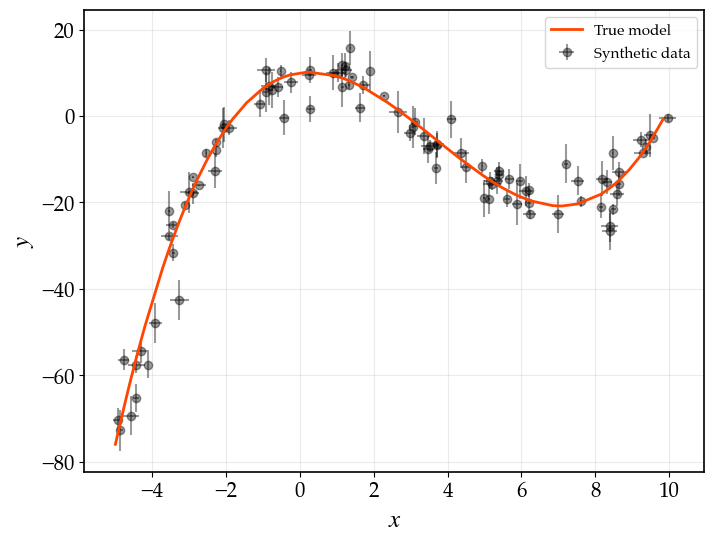

In [2]:

# Define Synthetic Model
# --------------------------------------------------- #
latex_eq = r"a_0 x^3 + a_1 x^2 + a_2 x + a_3"
coeffs_true = [0.2, -2.2, 1.2, 10]
sigma_x_int_true = 0.1
sigma_y_int_true = 1
sigma_xy_int_true = 0
observed_xerr = 0.25
observed_yerr = 5
(x_true, y_true, x_obs, y_obs, x_err, y_err) = \
    generate_synthetic_data(n_data=100, 
                            latex_eq=latex_eq, coeffs_true=coeffs_true, x_range=(-5, 10), 
                            sigma_x_int=sigma_x_int_true, sigma_y_int=sigma_y_int_true, x_err_max=observed_xerr, y_err_max=observed_yerr, 
                            seed=1)
# --------------------------------------------------- #



# Plot
# --------------------------------------------------- #
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(x_obs, y_obs, xerr=x_err, yerr=y_err, fmt="o", color="black", alpha=0.4, label="Synthetic data")
ax.plot(x_true, y_true, color="orangered", lw=2, label="True model", zorder=10)

ax.grid(alpha=0.25)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend()

plt.show()
# --------------------------------------------------- #


### Real Data (6-Order)

In [ ]:
import pandas as pd
df = pd.read_csv("/Users/hunter_brooks8/Documents/EOS/total_spec/EOS Sample - Platinum Sample.csv")
x_obs = df['sptnum_adp']
y_obs = df['Lbol']
Lbol_upper = np.abs(df['Lbol'] - df['Lbol_upper'])
Lbol_lower = np.abs(df['Lbol'] - df['Lbol_lower'])
y_err = 0.5*(Lbol_lower + Lbol_upper)

mask = np.isfinite(x_obs) & np.isfinite(y_obs) & np.isfinite(y_err)
x_obs = x_obs[mask]
y_obs = y_obs[mask]

x_err = [1]*len(y_err[mask])
y_err = y_err[mask]

plt.errorbar(x_obs, y_obs, xerr = x_err,yerr = y_err, fmt = 'o')

### Using Data


------------------------------------------
CosmicFit Model
------------------------------------------
LaTeX equation: a_0 x^3 + a_1 x^2 + a_2 x + a_3
Coefficients: [a_{0}, a_{1}, a_{2}, a_{3}]
Number of coefficients: 4
Total parameters: 7
------------------------------------------


------------------------------------------
Initial fit diagnostics
------------------------------------------
Initial coefficients: [ 0.19758344 -2.1977949   1.4376408   9.23837414]
Initial residual scatter: 4.418615140620903
Initial RMSE: 4.418615140620903
Initial log posterior: -290.3104964494497
------------------------------------------



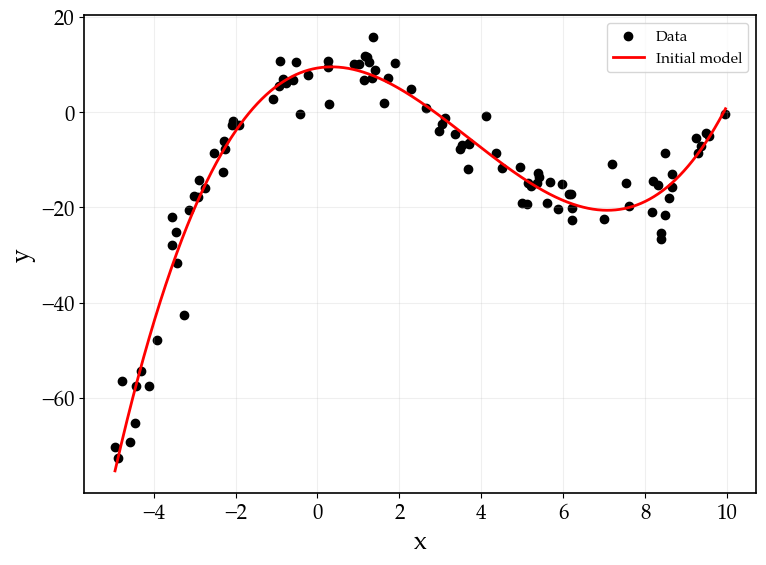

100%|██████████| 1000/1000 [00:20<00:00, 48.53it/s]


In [3]:
sampler = CosmicFit(x_obs, y_obs, xerr = x_err, yerr = y_err, nsteps=1000, nwalkers=50, ncores=6, quad_points = 1000, latex_eq=latex_eq)
# 

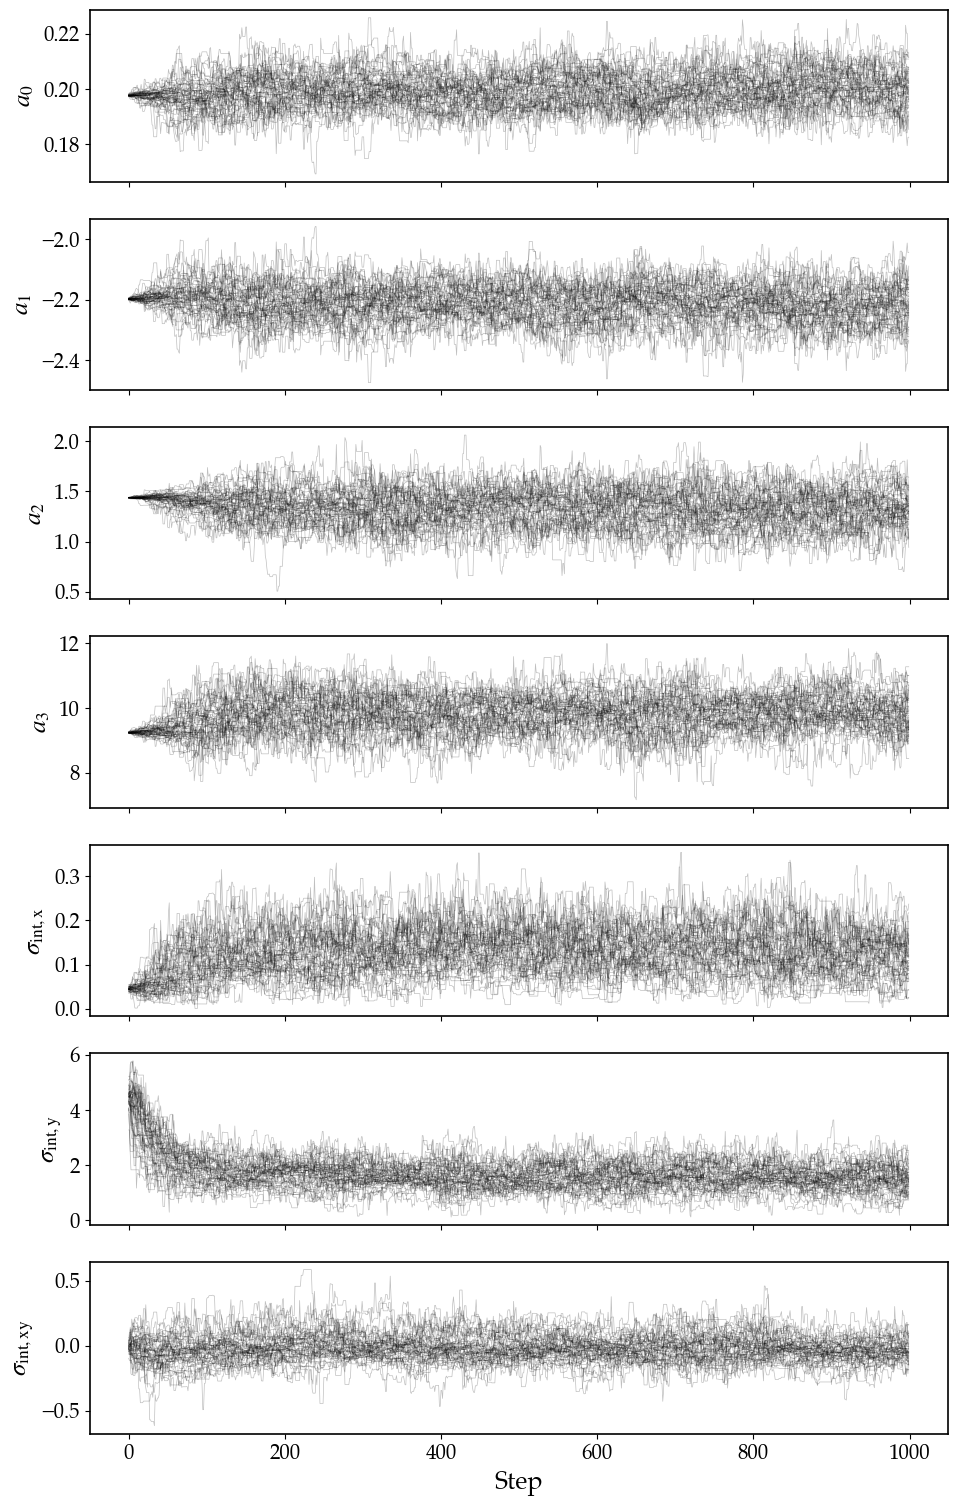

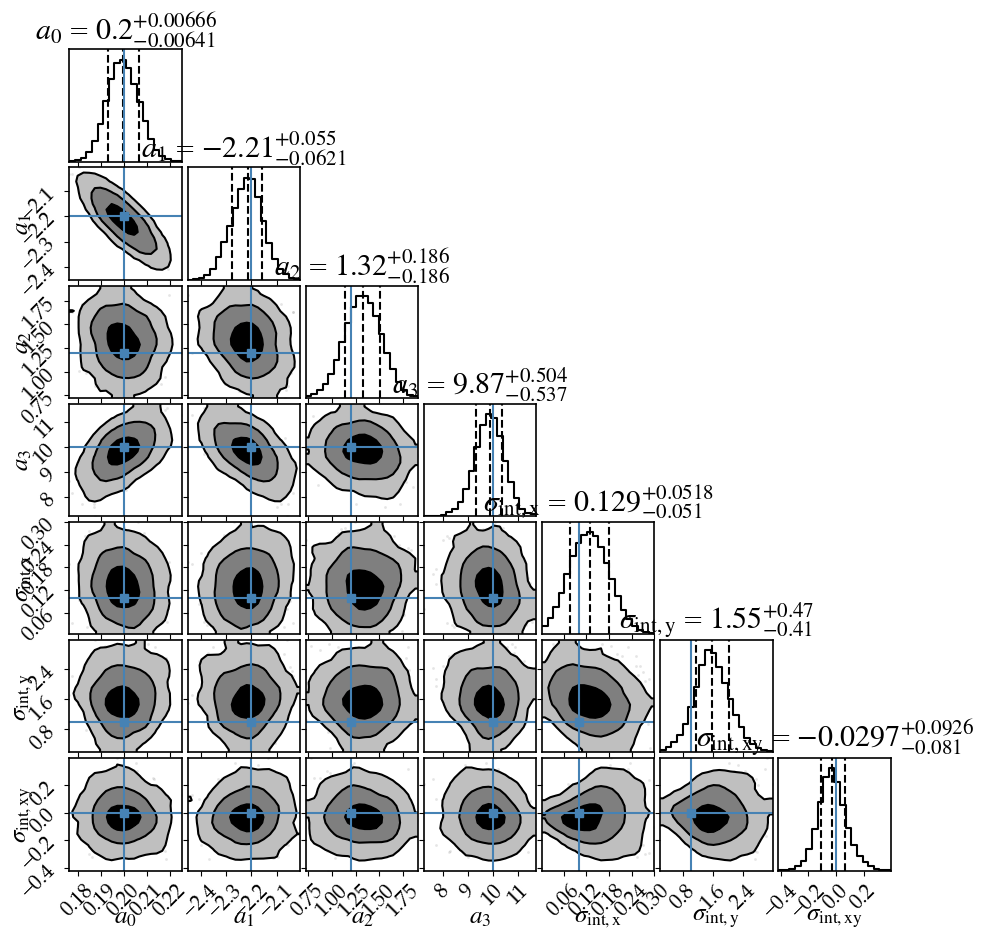

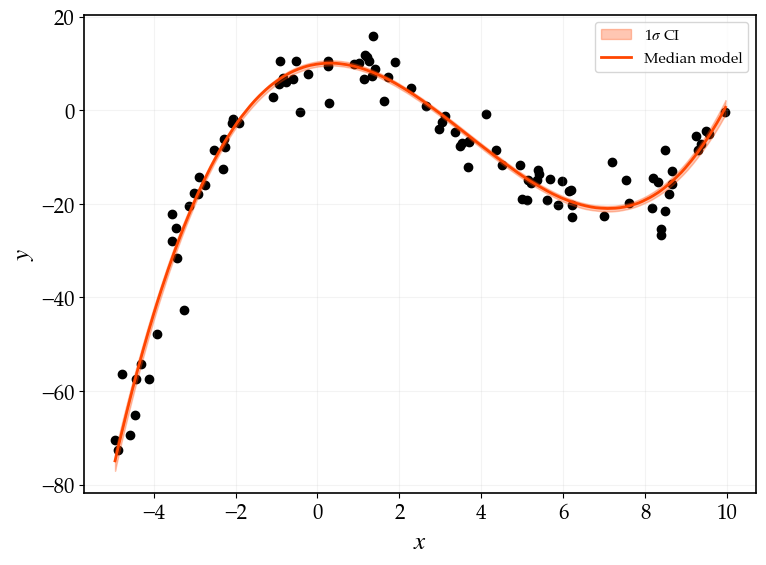

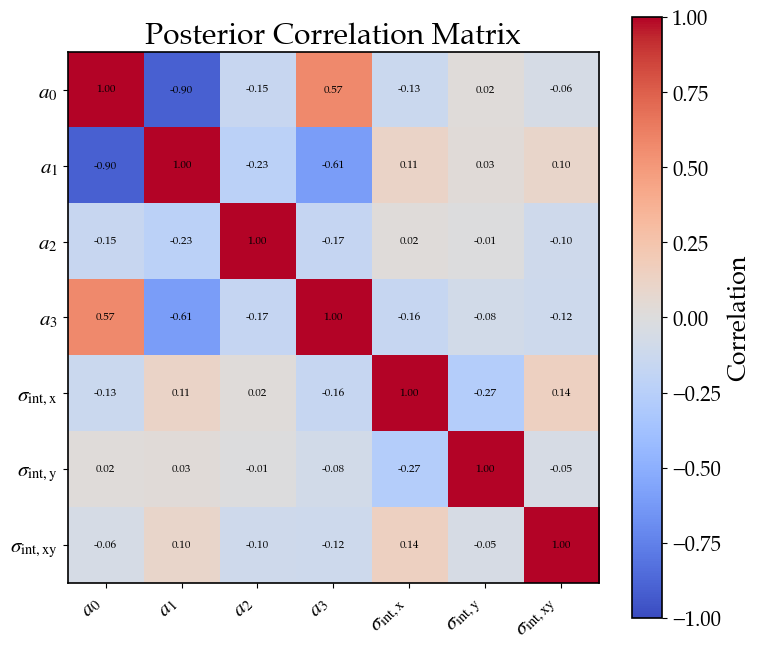


------------------------------------------
Posterior Coefficients
------------------------------------------
a_0  = 1.997386e-01 (+6.661066e-03, -6.410089e-03)
a_1  = -2.214346e+00 (+5.499398e-02, -6.209440e-02)
a_2  = 1.324434e+00 (+1.856853e-01, -1.855960e-01)
a_3  = 9.868530e+00 (+5.038062e-01, -5.369443e-01)

------------------------------------------
Cosmic Scatter
------------------------------------------
sigma_int_x  = 1.285458e-01 (+5.183068e-02, -5.098321e-02)
sigma_int_y  = 1.553199e+00 (+4.704168e-01, -4.103007e-01)
sigma_int_xy = -2.972650e-02 (+9.260174e-02, -8.102704e-02)

------------------------------------------
Covariance Matrix
------------------------------------------
[[ 4.17979614e-05 -3.46905150e-04 -1.81827203e-04  2.03277895e-03
  -4.24632435e-05  6.00127874e-05 -3.50571571e-05]
 [-3.46905150e-04  3.53615223e-03 -2.54362088e-03 -1.98676834e-02
   3.36749276e-04  6.81757848e-04  5.57488104e-04]
 [-1.81827203e-04 -2.54362088e-03  3.45725722e-02 -1.75488429e-02


In [5]:
test = CosmicAnalysis(sampler, x_obs, y_obs, latex_eq=latex_eq, burnin = 500, truths=coeffs_true, intrinsic_true=[sigma_x_int_true, sigma_y_int_true, sigma_xy_int_true])
# 

## okokugcina